In [1]:
# Import required libraries
!pip install -q kagglehub timm scikit-learn

import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from torchvision.datasets import ImageFolder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# Load the HAM10000/ISIC dataset used in Task 01
import kagglehub

path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

base_data_path = os.path.join(
    path, "Skin cancer ISIC The International Skin Imaging Collaboration"
)

print("Dataset path:", base_data_path)

100%|██████████| 786M/786M [00:19<00:00, 41.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration


In [3]:
# Prepare the same dataset classes and preprocessing used in Task 01
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = ImageFolder(
    os.path.join(base_data_path, "Train"),
    transform=transform
)

test_dataset = ImageFolder(
    os.path.join(base_data_path, "Test"),
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

classes = train_dataset.classes

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Classes:", classes)

Training images: 2239
Testing images: 118
Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [4]:
# Show HAM10000 class distribution
train_counts = pd.Series(train_dataset.targets).value_counts().sort_index()

distribution = pd.DataFrame({
    "Class": classes,
    "Images": train_counts.values
})

print(distribution)

                        Class  Images
0           actinic keratosis     114
1        basal cell carcinoma     376
2              dermatofibroma      95
3                    melanoma     438
4                       nevus     357
5  pigmented benign keratosis     462
6        seborrheic keratosis      77
7     squamous cell carcinoma     181
8             vascular lesion     139


In [5]:
# Define the required spatial-domain filters
def apply_filter(image, filter_name):
    image = np.array(image)

    if filter_name == "No Filter":
        return image

    if filter_name == "Average":
        return cv2.blur(image, (5, 5))

    if filter_name == "Gaussian":
        return cv2.GaussianBlur(image, (5, 5), 0)

    if filter_name == "Median":
        return cv2.medianBlur(image, 5)

    if filter_name == "Sharpening":
        kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
        return cv2.filter2D(image, -1, kernel)

    if filter_name == "Sobel":
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel = cv2.magnitude(sx.astype(np.float32), sy.astype(np.float32))
        sobel = cv2.normalize(sobel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return cv2.cvtColor(sobel, cv2.COLOR_GRAY2RGB)

In [6]:
# Create a dataset that applies one selected filter
class FilteredDataset(Dataset):
    def __init__(self, base_dataset, filter_name):
        self.base_dataset = base_dataset
        self.filter_name = filter_name

        self.to_tensor = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        image, label = self.base_dataset[index]
        image = image.permute(1, 2, 0).numpy()
        image = (image * np.array([0.229, 0.224, 0.225]) +
                 np.array([0.485, 0.456, 0.406])) * 255
        image = np.clip(image, 0, 255).astype(np.uint8)

        image = apply_filter(image, self.filter_name)
        image = self.to_tensor(image)

        return image, label

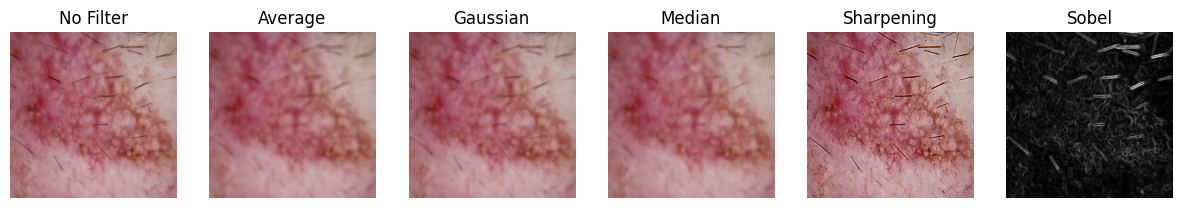

In [7]:
# Display original and required filtered images
sample_image, _ = train_dataset[0]
sample_image = sample_image.permute(1, 2, 0).numpy()
sample_image = np.clip(
    sample_image * np.array([0.229, 0.224, 0.225]) +
    np.array([0.485, 0.456, 0.406]), 0, 1
)

filters = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]

plt.figure(figsize=(15, 3))

for i, f in enumerate(filters):
    image = (sample_image * 255).astype(np.uint8)
    filtered = apply_filter(image, f)

    plt.subplot(1, 6, i + 1)
    plt.imshow(filtered)
    plt.title(f)
    plt.axis("off")

plt.show()

In [8]:
# Define the three best pretrained models from Task 01
model_names = ["vgg16", "resnet18", "resnet50"]
num_classes = len(classes)

print(model_names)

['vgg16', 'resnet18', 'resnet50']


In [9]:
# Load a pretrained model with the required number of classes
def load_model(name):
    model = timm.create_model(
        name,
        pretrained=True,
        num_classes=num_classes
    )
    return model.to(device)

In [10]:
# Train and evaluate one model with one filter
def train_and_evaluate(model_name, filter_name, epochs=1):

    dataset = FilteredDataset(train_dataset, filter_name)
    loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

    model = load_model(model_name)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)

    train_acc = []
    train_loss = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        running_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc.append(correct / total)
        train_loss.append(running_loss / len(loader))

    test_filtered = FilteredDataset(test_dataset, filter_name)
    test_loader_filtered = DataLoader(
        test_filtered, batch_size=32, shuffle=False, num_workers=2
    )

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in test_loader_filtered:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        auc = roc_auc_score(
            y_true, y_prob,
            multi_class="ovr",
            average="macro"
        )
    except:
        auc = np.nan

    return {
        "Model": model_name,
        "Filter": filter_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Macro-F1": macro_f1,
        "Balanced Accuracy": balanced_acc,
        "AUC": auc,
        "Train Accuracy": train_acc,
        "Train Loss": train_loss,
        "Confusion Matrix": confusion_matrix(y_true, y_pred),
        "Report": classification_report(
            y_true, y_pred,
            target_names=classes,
            zero_division=0
        )
    }

In [11]:
# Run all three models with no filter and the five required filters
results = []

for model_name in model_names:
    for filter_name in filters:
        print(model_name, "-", filter_name)

        result = train_and_evaluate(model_name, filter_name, epochs=1)
        results.append(result)

print("All experiments completed.")

vgg16 - No Filter


model.safetensors: reconstructing file:   0%|          |  0.00B /  553MB            

model.safetensors: downloading bytes:           |  0.00B            

vgg16 - Average
vgg16 - Gaussian
vgg16 - Median
vgg16 - Sharpening
vgg16 - Sobel
resnet18 - No Filter


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

resnet18 - Average
resnet18 - Gaussian
resnet18 - Median
resnet18 - Sharpening
resnet18 - Sobel
resnet50 - No Filter


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

resnet50 - Average
resnet50 - Gaussian
resnet50 - Median
resnet50 - Sharpening
resnet50 - Sobel
All experiments completed.


In [13]:
# Create the required comparison table
results_table = pd.DataFrame([
    {
        "Model": r["Model"],
        "Filter": r["Filter"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1-score": r["F1-score"],
        "Macro-F1": r["Macro-F1"],
        "AUC": r["AUC"]
    }
    for r in results
])

results_table

,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,AUC
0,vgg16,No Filter,0.474576,0.532436,0.474576,0.405733,0.409856,0.880814
1,vgg16,Average,0.457627,0.410283,0.457627,0.382912,0.404053,0.805498
2,vgg16,Gaussian,0.483051,0.426379,0.483051,0.416603,0.418764,0.848438
3,vgg16,Median,0.381356,0.472691,0.381356,0.281514,0.320963,0.834823
4,vgg16,Sharpening,0.415254,0.449163,0.415254,0.344062,0.342125,0.844827
5,vgg16,Sobel,0.271186,0.252144,0.271186,0.222017,0.259311,0.738522
6,resnet18,No Filter,0.288136,0.164661,0.288136,0.208174,0.170587,0.727919
7,resnet18,Average,0.228814,0.126286,0.228814,0.158371,0.129776,0.730644
8,resnet18,Gaussian,0.194915,0.164582,0.194915,0.153113,0.125468,0.683003
9,resnet18,Median,0.271186,0.183149,0.271186,0.182130,0.149245,0.758021


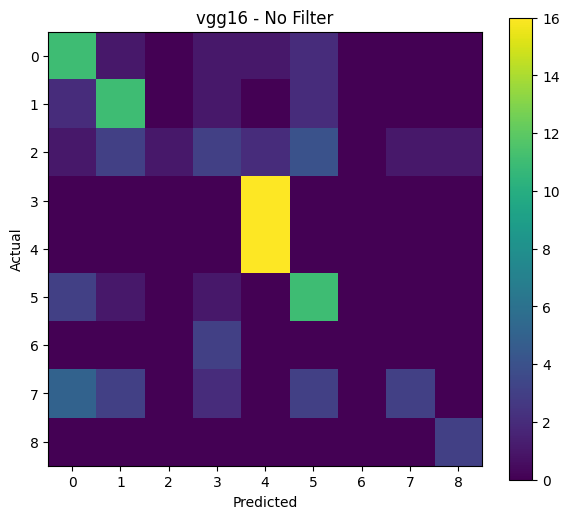

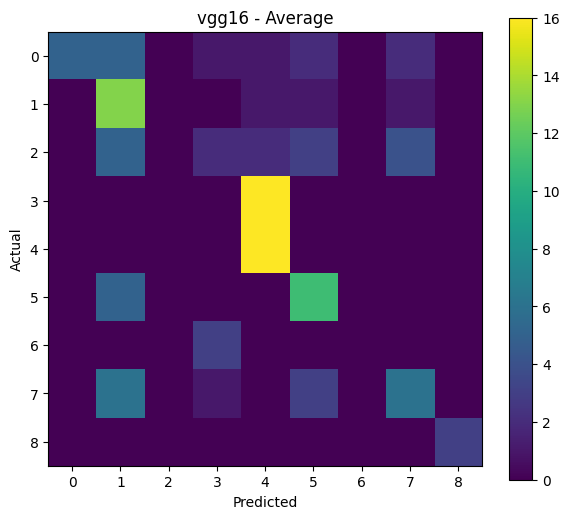

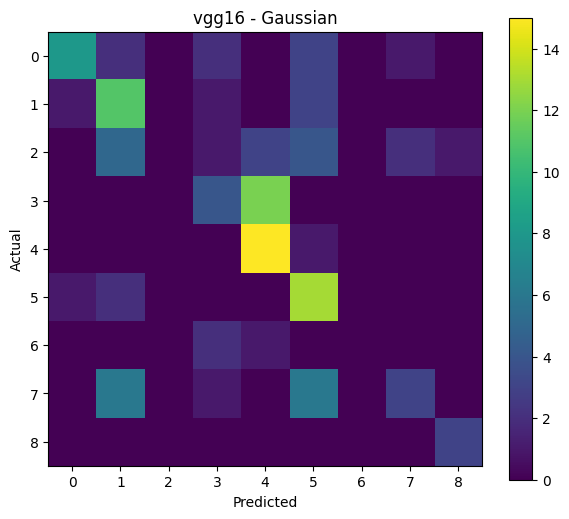

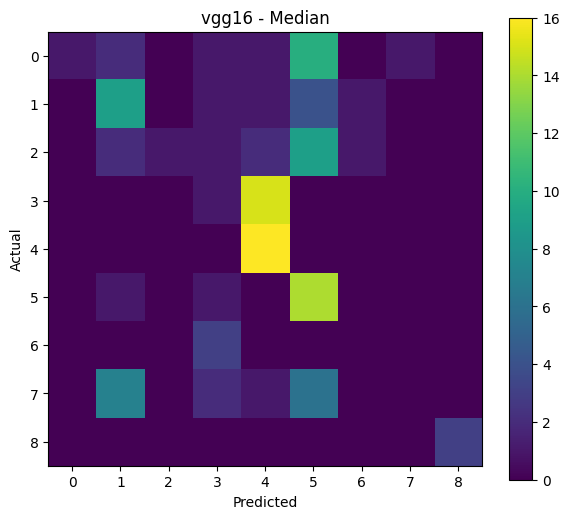

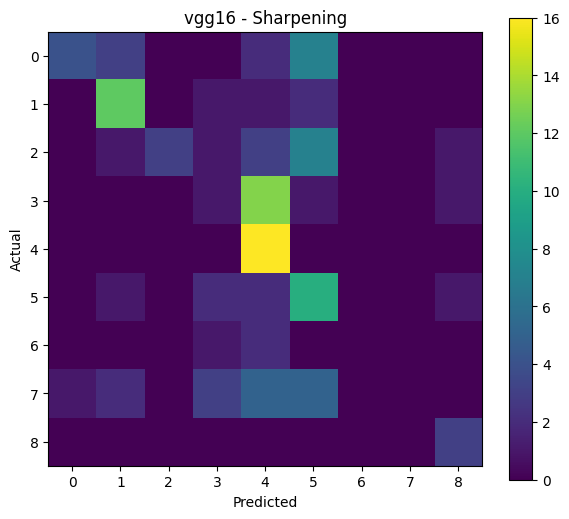

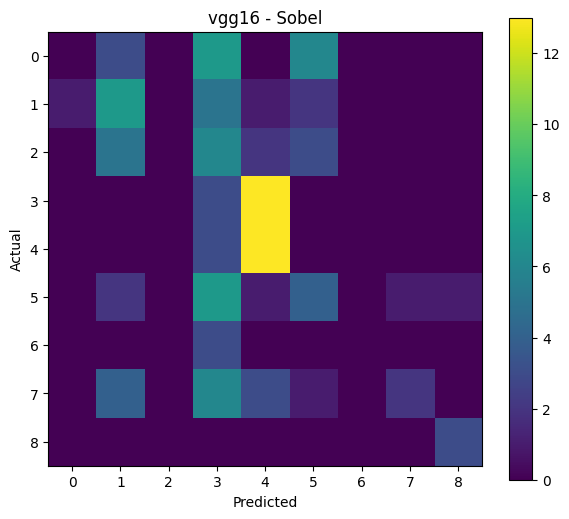

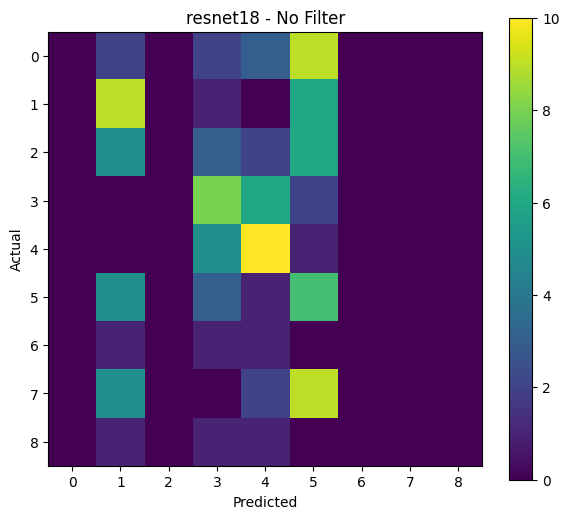

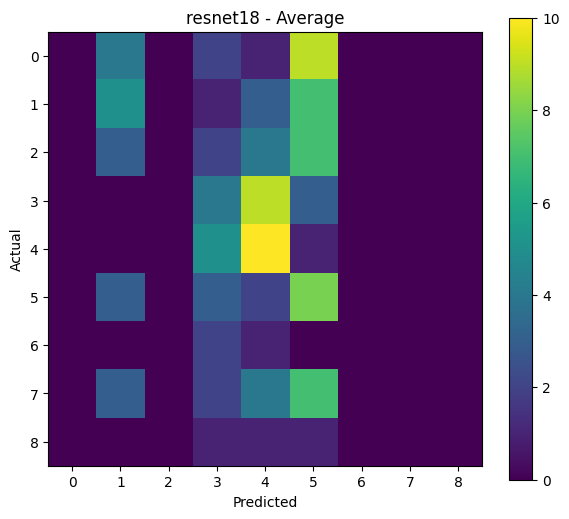

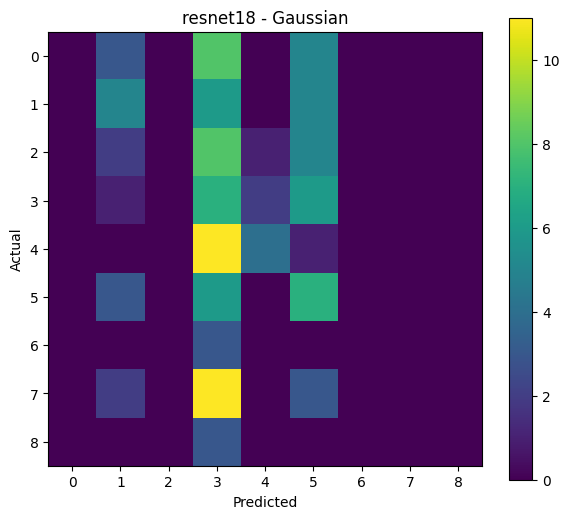

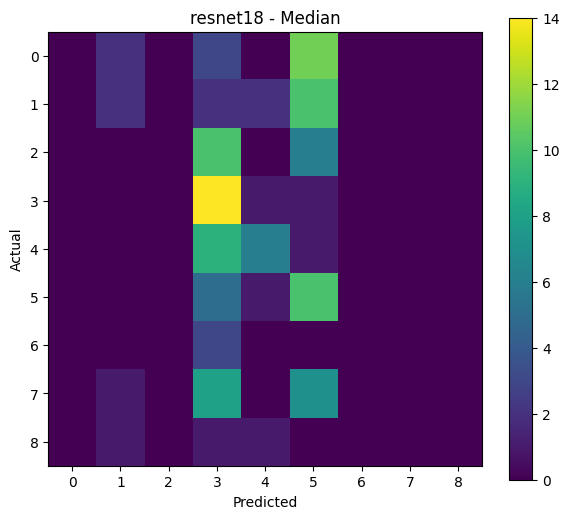

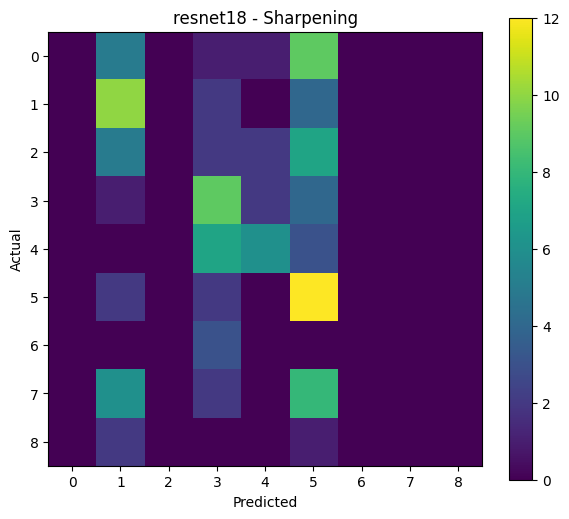

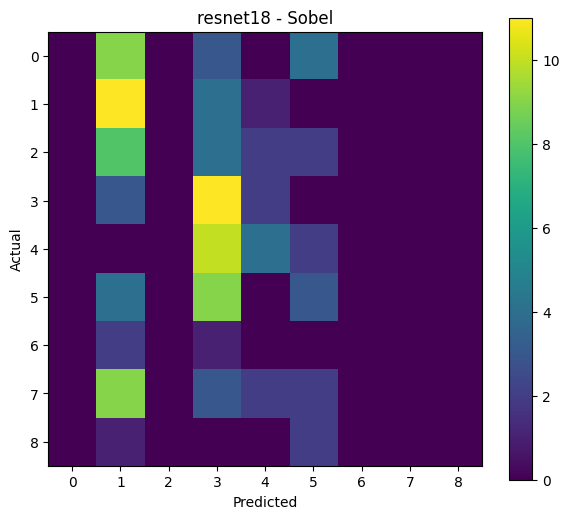

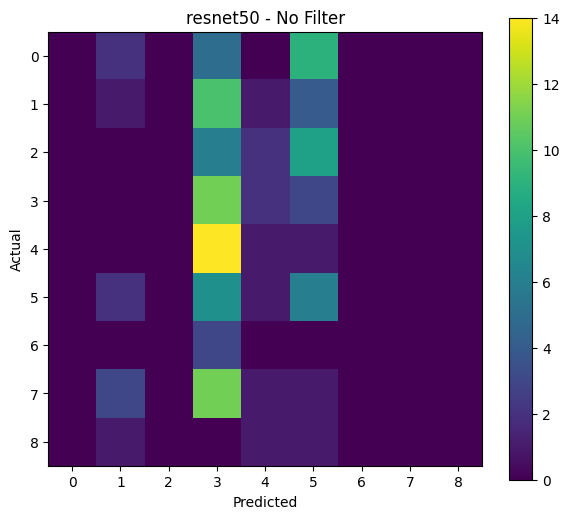

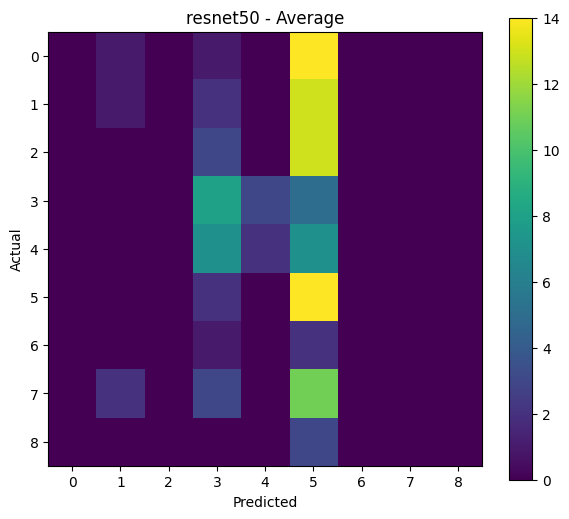

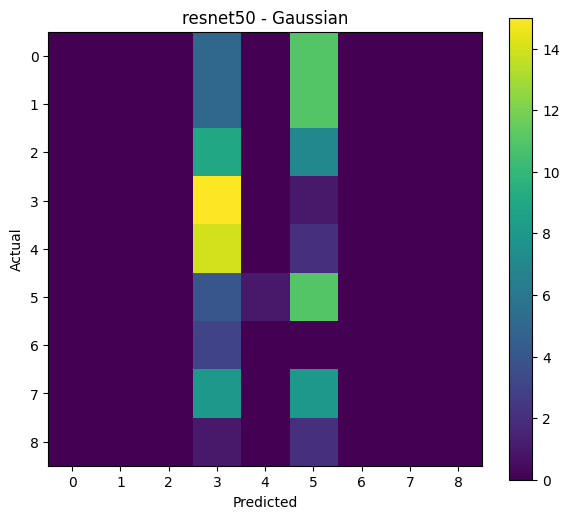

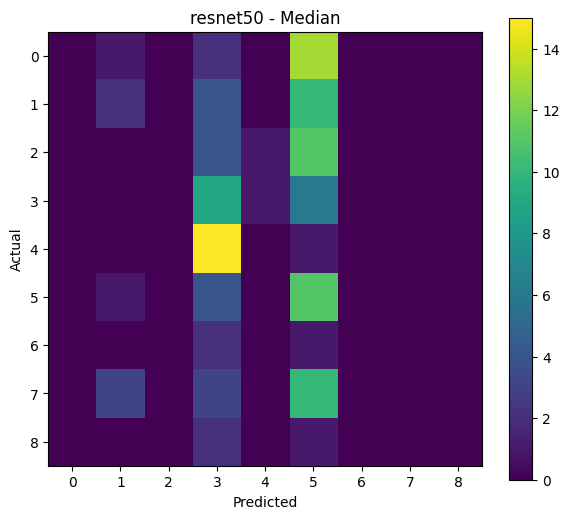

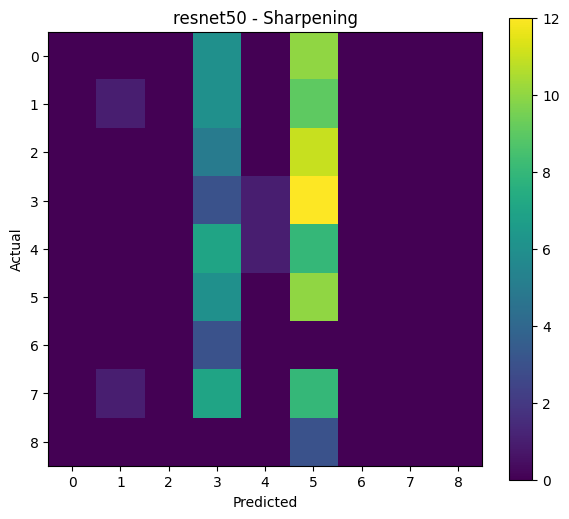

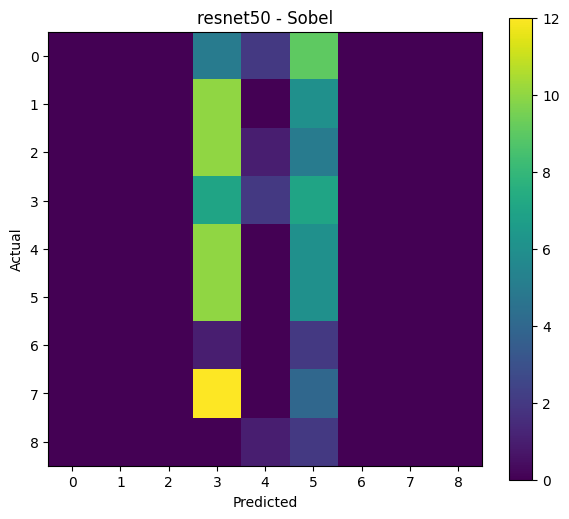

In [14]:
# Display confusion matrices for all experiments
for r in results:
    plt.figure(figsize=(7, 6))
    plt.imshow(r["Confusion Matrix"])
    plt.title(f'{r["Model"]} - {r["Filter"]}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.show()

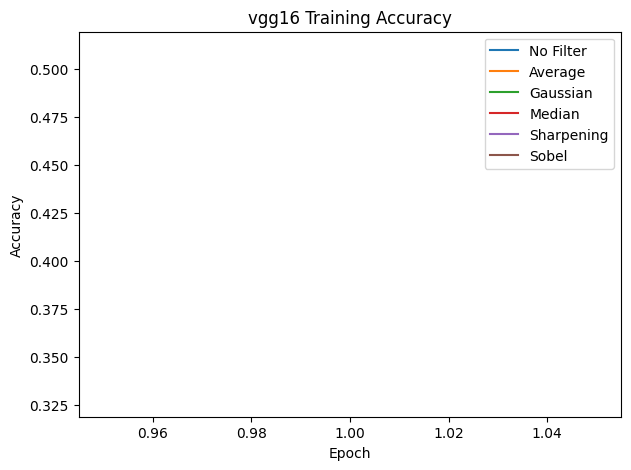

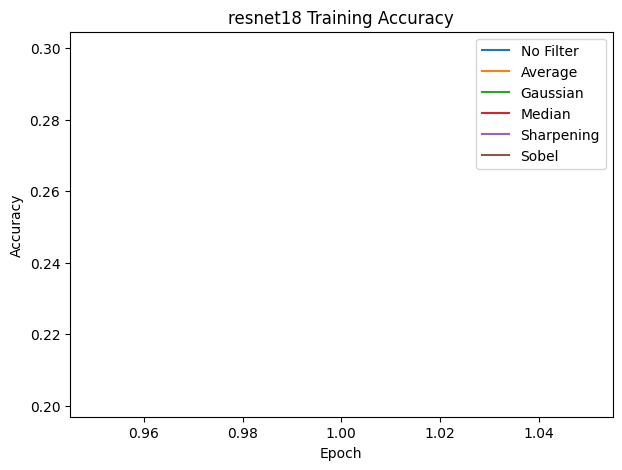

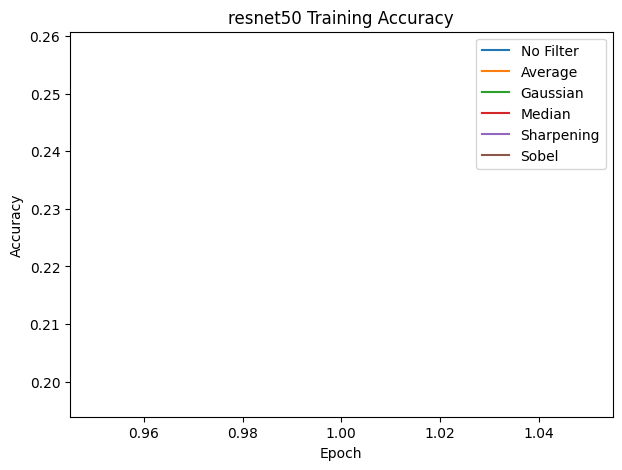

In [15]:
# Plot training accuracy curves
for model_name in model_names:
    plt.figure(figsize=(7, 5))

    for r in results:
        if r["Model"] == model_name:
            plt.plot(
                range(1, len(r["Train Accuracy"]) + 1),
                r["Train Accuracy"],
                label=r["Filter"]
            )

    plt.title(f"{model_name} Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

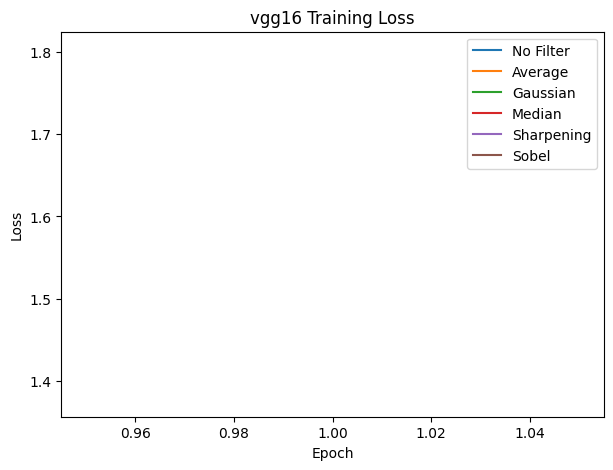

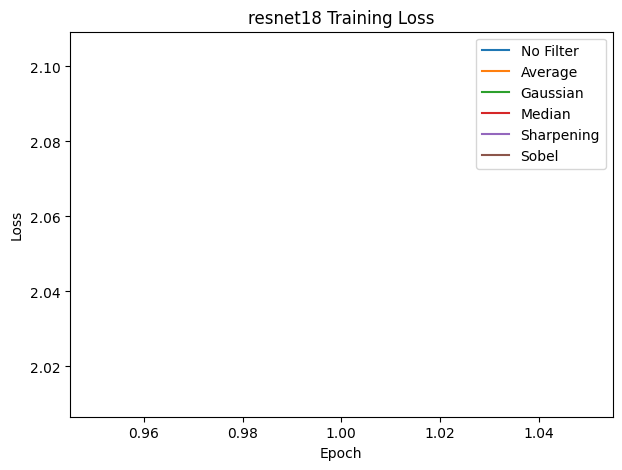

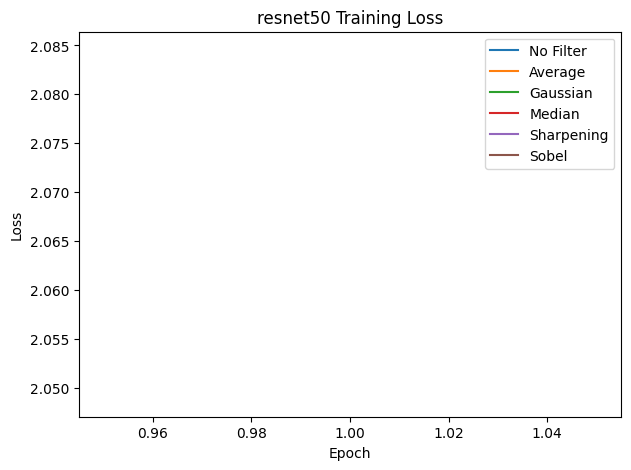

In [16]:
# Plot training loss curves
for model_name in model_names:
    plt.figure(figsize=(7, 5))

    for r in results:
        if r["Model"] == model_name:
            plt.plot(
                range(1, len(r["Train Loss"]) + 1),
                r["Train Loss"],
                label=r["Filter"]
            )

    plt.title(f"{model_name} Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [17]:
# Show per-class precision, recall and F1-score
for r in results:
    print("\n", r["Model"], "-", r["Filter"])
    print(r["Report"])


 vgg16 - No Filter
                            precision    recall  f1-score   support

         actinic keratosis       0.50      0.69      0.58        16
      basal cell carcinoma       0.58      0.69      0.63        16
            dermatofibroma       1.00      0.06      0.12        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.46      1.00      0.63        16
pigmented benign keratosis       0.50      0.69      0.58        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.75      0.19      0.30        16
           vascular lesion       0.75      1.00      0.86         3

                  accuracy                           0.47       118
                 macro avg       0.50      0.48      0.41       118
              weighted avg       0.53      0.47      0.41       118


 vgg16 - Average
                            precision    recall  f1-score   support

      

In [21]:
results_table = pd.DataFrame([
    {
        "Model": r["Model"],
        "Filter": r["Filter"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1-score": r["F1-score"],
        "Macro-F1": r["Macro-F1"],
        "Balanced Accuracy": r["Balanced Accuracy"],
        "AUC": r["AUC"]
    }
    for r in results
])

comparison = results_table.copy()

baseline = comparison[
    comparison["Filter"] == "No Filter"
][["Model", "Accuracy", "Macro-F1", "Balanced Accuracy"]]

baseline = baseline.rename(columns={
    "Accuracy": "Baseline Accuracy",
    "Macro-F1": "Baseline Macro-F1",
    "Balanced Accuracy": "Baseline Balanced Accuracy"
})

comparison = comparison.merge(baseline, on="Model")

comparison["Accuracy Change"] = (
    comparison["Accuracy"] - comparison["Baseline Accuracy"]
)

comparison["Macro-F1 Change"] = (
    comparison["Macro-F1"] - comparison["Baseline Macro-F1"]
)

comparison["Balanced Accuracy Change"] = (
    comparison["Balanced Accuracy"] -
    comparison["Baseline Balanced Accuracy"]
)

comparison

,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Baseline Accuracy,Baseline Macro-F1,Baseline Balanced Accuracy,Accuracy Change,Macro-F1 Change,Balanced Accuracy Change
0,vgg16,No Filter,0.474576,0.532436,0.474576,0.405733,0.409856,0.479167,0.880814,0.474576,0.409856,0.479167,0.000000,0.000000,0.000000
1,vgg16,Average,0.457627,0.410283,0.457627,0.382912,0.404053,0.465278,0.805498,0.474576,0.409856,0.479167,-0.016949,-0.005803,-0.013889
2,vgg16,Gaussian,0.483051,0.426379,0.483051,0.416603,0.418764,0.486111,0.848438,0.474576,0.409856,0.479167,0.008475,0.008908,0.006944
3,vgg16,Median,0.381356,0.472691,0.381356,0.281514,0.320963,0.402778,0.834823,0.474576,0.409856,0.479167,-0.093220,-0.088894,-0.076389
4,vgg16,Sharpening,0.415254,0.449163,0.415254,0.344062,0.342125,0.430556,0.844827,0.474576,0.409856,0.479167,-0.059322,-0.067732,-0.048611
5,vgg16,Sobel,0.271186,0.252144,0.271186,0.222017,0.259311,0.312500,0.738522,0.474576,0.409856,0.479167,-0.203390,-0.150545,-0.166667
6,resnet18,No Filter,0.288136,0.164661,0.288136,0.208174,0.170587,0.236111,0.727919,0.288136,0.170587,0.236111,0.000000,0.000000,0.000000
7,resnet18,Average,0.228814,0.126286,0.228814,0.158371,0.129776,0.187500,0.730644,0.288136,0.170587,0.236111,-0.059322,-0.040810,-0.048611
8,resnet18,Gaussian,0.194915,0.164582,0.194915,0.153113,0.125468,0.159722,0.683003,0.288136,0.170587,0.236111,-0.093220,-0.045119,-0.076389
9,resnet18,Median,0.271186,0.183149,0.271186,0.182130,0.149245,0.222222,0.758021,0.288136,0.170587,0.236111,-0.016949,-0.021341,-0.013889


In [24]:
# Print the results needed to answer the Task 02 questions
for model in model_names:
    print("\nMODEL:", model)
    print(
        comparison[comparison["Model"] == model][
            ["Filter", "Accuracy", "Macro-F1",
             "Balanced Accuracy", "AUC"]
        ].to_string(index=False)
    )


MODEL: vgg16
    Filter  Accuracy  Macro-F1  Balanced Accuracy      AUC
 No Filter  0.474576  0.409856           0.479167 0.880814
   Average  0.457627  0.404053           0.465278 0.805498
  Gaussian  0.483051  0.418764           0.486111 0.848438
    Median  0.381356  0.320963           0.402778 0.834823
Sharpening  0.415254  0.342125           0.430556 0.844827
     Sobel  0.271186  0.259311           0.312500 0.738522

MODEL: resnet18
    Filter  Accuracy  Macro-F1  Balanced Accuracy      AUC
 No Filter  0.288136  0.170587           0.236111 0.727919
   Average  0.228814  0.129776           0.187500 0.730644
  Gaussian  0.194915  0.125468           0.159722 0.683003
    Median  0.271186  0.149245           0.222222 0.758021
Sharpening  0.313559  0.183785           0.256944 0.731305
     Sobel  0.245763  0.133301           0.201389 0.663961

MODEL: resnet50
    Filter  Accuracy  Macro-F1  Balanced Accuracy      AUC
 No Filter  0.161017  0.074440           0.131944 0.645570
   Avera